In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, roc_auc_score)

df = pd.read_csv(r"C:\Users\k9481\OneDrive\Documents\ml databases\creditcard.csv")



In [11]:
print(df.shape)


(284807, 31)


In [12]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [15]:
df.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [16]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [17]:
print("All columns:")
print(df.columns.tolist())
print("\nDataframe shape:")
print(df.shape)
print("\nFirst few columns:")
print(df.head())

All columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dataframe shape:
(284807, 31)

First few columns:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.1671

Column            Meaning
V1-V28            Anonymous features (PCA transformed for privacy)
Amount            Transaction amount
Time              Seconds elapsed since first transaction
Class             Target — 0=Normal, 1=Fraudulent

<!-- Understand the Imbalance Problem 

In [18]:
# Check class distribution
print("Class distribution:")
print(df['Class'].value_counts())
print("\nPercentage:")
print(df['Class'].value_counts(normalize=True) * 100)

# You'll see something like:
# 0 (Normal)     : ~99.8%
# 1 (Fraudulent) : ~0.2%

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [19]:
X = df.drop('Class', axis=1)
y = df['Class']

# Split with stratify (maintain fraud ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale (fraud detection needs scaling)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (227845, 30)
Test shape : (56962, 30)


In [20]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # NEW! Handle imbalance
    #class_weight='balanced' tells the model to care equally about both classes even though fraud is rare.
)

print("Training... (this takes a minute)")
model.fit(X_train, y_train)
print("Done!")

Training... (this takes a minute)
Done!


In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob[:, 1]))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.9995084442259752
ROC-AUC  : 0.9529050875414883

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
 [[56861     3]
 [   25    73]]


Why ROC-AUC here?

Accuracy is useless on imbalanced data (you'd get 99.8% by predicting all normal)
ROC-AUC tells you how well the model separates fraud from normal

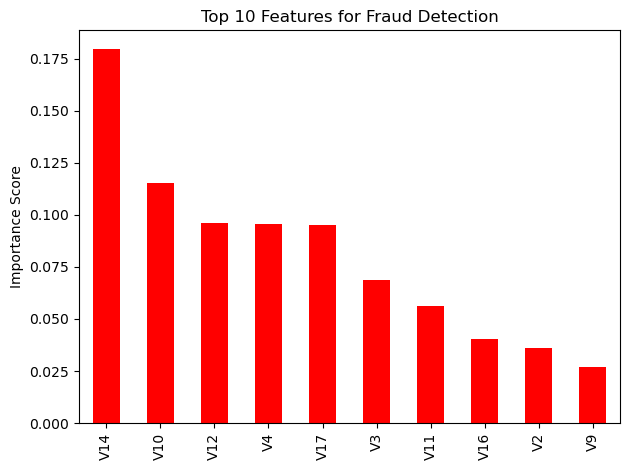

V14    0.179738
V10    0.115455
V12    0.096318
V4     0.095611
V17    0.095131
V3     0.068694
V11    0.056131
V16    0.040341
V2     0.036234
V9     0.026945
dtype: float64


In [22]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns.tolist()
)

importance.sort_values(ascending=False).head(10).plot(kind='bar', color='red')
plt.title("Top 10 Features for Fraud Detection")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False).head(10))

In [23]:
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)
train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test, y_prob[:, 1])

print(f"Train Accuracy : {train_acc:.2f}  |  Train ROC-AUC : {train_auc:.2f}")
print(f"Test Accuracy  : {test_acc:.2f}  |  Test ROC-AUC  : {test_auc:.2f}")
print(f"Gap (Accuracy) : {train_acc - test_acc:.2f}")
print(f"Gap (ROC-AUC)  : {train_auc - test_auc:.2f}")

Train Accuracy : 1.00  |  Train ROC-AUC : 1.00
Test Accuracy  : 1.00  |  Test ROC-AUC  : 0.95
Gap (Accuracy) : 0.00
Gap (ROC-AUC)  : 0.05


In [24]:
print("Finding best number of trees (this takes 2-3 minutes)...\n")

for n in [50, 100, 150, 200]:
    m = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1, class_weight='balanced')
    m.fit(X_train, y_train)
    test_auc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    print(f"Trees: {n:3d}  ->  ROC-AUC: {test_auc:.4f}")

Finding best number of trees (this takes 2-3 minutes)...

Trees:  50  ->  ROC-AUC: 0.9534
Trees: 100  ->  ROC-AUC: 0.9529
Trees: 150  ->  ROC-AUC: 0.9576
Trees: 200  ->  ROC-AUC: 0.9572


In [25]:
normal_txn = [[0, -1.3598, -0.0747, 2.3601, -0.5933, -0.2858, -0.0755, 0.0800, 0.0851, -0.2549, -0.6628, -0.4537, -0.2418, 0.5020, 0.2019, 0.2155, 0.3168, 0.4464, 0.1017, 0.6419, 0.0629, 0.0213, 0.0464, 0.2626, 0.5622, 0.5140, 0.5819, 0.9608, 149.62]]

result = model.predict([normal_txn[0]])
prob   = model.predict_proba([normal_txn[0]])

print("Transaction 1 (Normal):", "🚫 FRAUD" if result[0] == 1 else "✅ NORMAL")
print("Fraud Probability:", round(prob[0][1] * 100, 2), "%")

ValueError: X has 29 features, but RandomForestClassifier is expecting 30 features as input.

In [26]:
print("Features the model expects:")
print(X.columns.tolist())
print("Total features:", len(X.columns))

Features the model expects:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Total features: 30


In [27]:
normal_txn = [0, -1.3598, -0.0747, 2.3601, -0.5933, -0.2858, -0.0755, 0.0800, 0.0851, -0.2549, -0.6628, -0.4537, -0.2418, 0.5020, 0.2019, 0.2155, 0.3168, 0.4464, 0.1017, 0.6419, 0.0629, 0.0213, 0.0464, 0.2626, 0.5622, 0.5140, 0.5819, 0.9608, -0.0451, 149.62]

result = model.predict([normal_txn])
prob   = model.predict_proba([normal_txn])

print("Txn 1:", "🚫 FRAUD" if result[0] == 1 else "✅ NORMAL")
print("Fraud Probability:", round(prob[0][1] * 100, 2), "%\n")

Txn 1: ✅ NORMAL
Fraud Probability: 0.0 %



In [28]:
fraud_txn = [1000, 1.2091, -1.0681, 2.8945, 1.2891, 0.8956, -0.2857, 1.4231, 0.9876, -0.4234, 1.6321, -0.9876, 1.2345, -0.6789, 0.5432, -0.3210, 0.1234, -0.9999, 0.4567, 0.8901, -0.1234, 0.5678, 0.9012, -0.3456, 0.7890, -0.2345, 0.1111, -0.9999, 0.8765, 3450.75]

result = model.predict([fraud_txn])
prob   = model.predict_proba([fraud_txn])

print("Txn 2:", "🚫 FRAUD" if result[0] == 1 else "✅ NORMAL")
print("Fraud Probability:", round(prob[0][1] * 100, 2), "%\n")

Txn 2: ✅ NORMAL
Fraud Probability: 1.0 %



In [29]:
large_txn = [5000, -0.5234, 0.3210, 1.2345, -0.6789, 0.4567, 0.1234, -0.8901, 0.2345, -0.6789, 0.5432, 0.1234, -0.9876, 0.3456, -0.7890, 0.2345, 0.1111, -0.9999, 0.4567, 0.8901, -0.1234, 0.5678, 0.9012, -0.3456, 0.7890, -0.2345, 0.1111, -0.9999, 0.2345, 5999.99]

result = model.predict([large_txn])
prob   = model.predict_proba([large_txn])

print("Txn 3:", "🚫 FRAUD" if result[0] == 1 else "✅ NORMAL")
print("Fraud Probability:", round(prob[0][1] * 100, 2), "%")

Txn 3: ✅ NORMAL
Fraud Probability: 2.0 %
